<a href="https://colab.research.google.com/github/vanashreenarvekar-hub/Data-Engineering/blob/main/DataEngineering_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Practical No. 4|Vanshree Narvekar|R.No:29

Original Dataset:
   Age  Marks  Attendance  Constant
0   20     75          85         1
1   21     80          88         1
2   22     85          90         1
3   23     90          92         1
4   24     95          94         1
5  100     20          50         1

Dataset after Noise Elimination:
   Age  Marks  Attendance  Constant
0   20     75          85         1
1   21     80          88         1
2   22     85          90         1
3   23     90          92         1
4   24     95          94         1

Selected Features:
Index(['Age', 'Marks', 'Attendance'], dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
Index: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Age         5 non-null      int64
 1   Marks       5 non-null      int64
 2   Attendance  5 non-null      int64
 3   Constant    5 non-null      int64
dtypes: int64(4)
memory usage: 200.0 bytes

Statistical

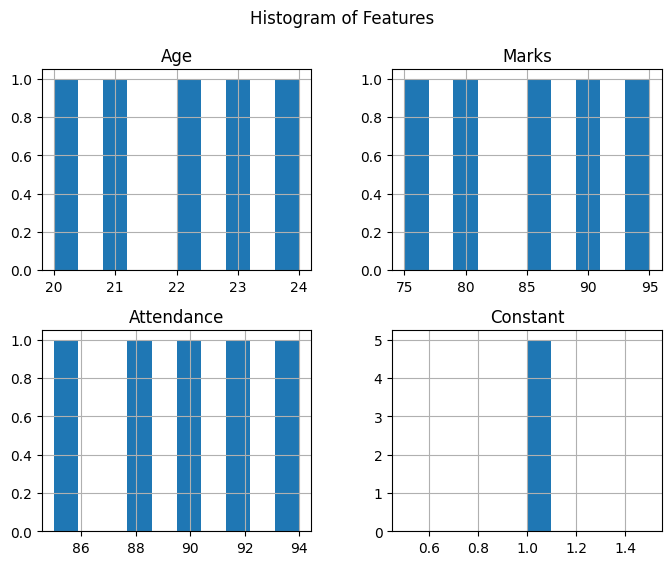

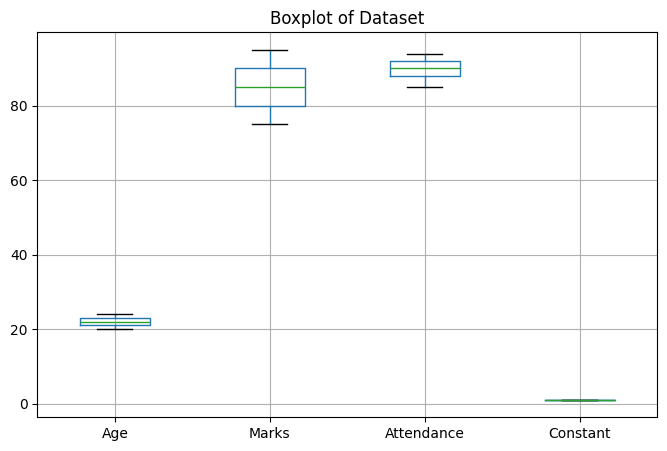

In [1]:
#Python Program demonstrating Noise Elimination Feature Selection, and EDA Using Pandas, Matplotlib, and scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import VarianceThreshold

# Sample Dataset
data = {
    'Age': [20, 21, 22, 23, 24, 100],
    'Marks': [75, 80, 85, 90, 95, 20],
    'Attendance': [85, 88, 90, 92, 94, 50],
    'Constant': [1, 1, 1, 1, 1, 1]
}

df = pd.DataFrame(data)

print("Original Dataset:")
print(df)

# 1. Noise Elimination

Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_clean = df[
    (df['Age'] >= lower) &
    (df['Age'] <= upper)
]

print("\nDataset after Noise Elimination:")
print(df_clean)

# 2. Feature Selection

selector = VarianceThreshold(threshold=0.0)
selected = selector.fit_transform(df_clean)

selected_columns = df_clean.columns[
    selector.get_support()
]

print("\nSelected Features:")
print(selected_columns)

# 3. Exploratory Data Analysis

print("\nDataset Information:")
df_clean.info()

print("\nStatistical Summary:")
print(df_clean.describe())

print("\nCorrelation Matrix:")
print(df_clean.corr())

# Histogram
df_clean.hist(figsize=(8, 6))
plt.suptitle("Histogram of Features")
plt.show()

# Boxplot
df_clean.boxplot(figsize=(8, 5))
plt.title("Boxplot of Dataset")
plt.show()
